# 전체 코드 흐름 개요 (LightGBM + Optuna 하이퍼파라미터 튜닝)

이 노트북은 **LightGBM 학습/평가** 후, **Optuna 기반 하이퍼파라미터 튜닝**을 통해
디지털 소외계층을 3단계로 분류하는 성능을 개선하는 실험 파이프라인을 갖는다.

---
## 1) 파이프라인 단계 (메인 실행 흐름)

**단계 1. 환경/재현성/경로 초기화**
- 라이브러리 import
- 프로젝트 루트/입출력 경로 설정 (환경변수 우선, 없으면 자동 탐색)
- model_config에서 공통 feature·평가 지표 import

**단계 2. 데이터 로딩 및 라벨 정규화**
- train/val/test 데이터 로드
- 레이블을 0-based(0,1,2)로 변환

**단계 3. Baseline LightGBM 학습**
- 기본 파라미터로 먼저 학습
- val/test 성능 확인 (튜닝 전 기준점)

**단계 4. Optuna 하이퍼파라미터 튜닝**
- TPE Sampler 기반 베이지안 최적화
- val F1-macro 최대화
- 탐색 파라미터: num_leaves, max_depth, learning_rate, n_estimators 등

**단계 5. 최적 파라미터로 최종 학습 (학습 곡선 동시 기록)**
- record_evaluation 콜백으로 단일 학습에서 곡선 기록
- early stopping으로 과적합 방지

**단계 6. val/test 평가**
- model_config.evaluate() 공통 함수 사용
- MLP·SVM과 동일 형식

**단계 7. 시각화**
- 학습 곡선
- Test Set 예측 결과 (Confusion Matrix / 분포 / 정답비율)

**단계 8. Feature Importance 분석**
- Split Count / Gain 두 기준 비교

---
## 2) 주요 산출물
- `lgbm_training_curve.png`         # 학습 곡선
- `lgbm_prediction_results.png`     # Test Set 예측 결과 시각화
- `LightGBM_evaluation.txt`         # val/test 성능 리포트
- `lgbm_feature_importance.png`     # Feature Importance 시각화
- `lgbm_feature_importance.csv`     # Feature Importance 수치
- `lgbm_optuna_trials.csv`          # Optuna 탐색 결과
- `lgbm_summary.json`               # 최종 성능 요약

## 3) 권고
- GPU 없이 CPU 환경에서도 실행 가능함 (`n_jobs=-1`로 멀티코어 자동 활용).
- Optuna N_TRIALS=50 기준 약 10~15분 소요 (CPU 기준).


## [단계 1] 환경/재현성/경로 초기화

In [5]:
# ____________________________________________________________
# [파이프라인 단계 1] 환경/재현성/경로 초기화
# ____________________________________________________________

from pathlib import Path
import os, sys, warnings, json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

import lightgbm as lgb
import optuna
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 한글 폰트 설정 (MLP 노트북과 동일 방식)
for font in ['Malgun Gothic', 'AppleGothic', 'NanumGothic']:
    if font in {f.name for f in fm.fontManager.ttflist}:
        plt.rcParams['font.family'] = font
        break
plt.rcParams['axes.unicode_minus'] = False

# 환경변수 PROJECT_ROOT가 있으면 우선 사용, 없으면 현재 디렉토리부터 탐색
# (MLP 노트북과 완전히 동일한 로직)
def find_project_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if ((candidate / '.git').exists() or (candidate / 'notebooks').exists()) \
                and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError('Project root not found.')

PROJECT_ROOT = (
    Path(os.environ['PROJECT_ROOT']).expanduser().resolve()
    if 'PROJECT_ROOT' in os.environ
    else find_project_root(Path.cwd())
)

DATA_DIR   = PROJECT_ROOT / 'data' / 'labeled'
OUTPUT_DIR = PROJECT_ROOT / 'models' / 'LightGBM'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 필수 데이터 파일 존재 여부 확인
for name in ['train_labeled.csv', 'val_labeled.csv', 'test_labeled.csv']:
    if not (DATA_DIR / name).exists():
        raise FileNotFoundError(f'Missing: {DATA_DIR / name}')

# model_config 모듈 import (MLP 노트북과 동일)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from models.model_config import MODEL_FEATURES, TARGET_COL, EVAL_METRICS, evaluate

SEED = 42
CLASS_NAMES = ['1단계_완전소외', '2단계_부분적응', '3단계_자립적응']

print('Project root:', PROJECT_ROOT)
print('Output dir  :', OUTPUT_DIR)
print('Features    :', len(MODEL_FEATURES), '/ Target:', TARGET_COL)
print('Eval metrics:', EVAL_METRICS)


Project root: C:\Users\user\Desktop\기계학습 기초_개인work - 복사본 (2)\Team-3
Output dir  : C:\Users\user\Desktop\기계학습 기초_개인work - 복사본 (2)\Team-3\models\LightGBM
Features    : 118 / Target: digital_stage
Eval metrics: ('accuracy', 'macro_f1', 'weighted_f1')


c:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## [단계 2] 데이터 로딩 및 라벨 정규화

In [6]:
# ____________________________________________________________
# [파이프라인 단계 2] 데이터 로딩 및 라벨 정규화
# ____________________________________________________________

train_df = pd.read_csv(DATA_DIR / 'train_labeled.csv')
val_df   = pd.read_csv(DATA_DIR / 'val_labeled.csv')
test_df  = pd.read_csv(DATA_DIR / 'test_labeled.csv')

# LightGBM도 0-based 인덱스 사용: 1,2,3 → 0,1,2 (MLP·SVM과 동일)
for df in [train_df, val_df, test_df]:
    df['digital_stage'] -= 1

X_train = train_df[MODEL_FEATURES].values.astype('float32')
y_train = train_df[TARGET_COL].values.astype('int32')
X_val   = val_df[MODEL_FEATURES].values.astype('float32')
y_val   = val_df[TARGET_COL].values.astype('int32')
X_test  = test_df[MODEL_FEATURES].values.astype('float32')
y_test  = test_df[TARGET_COL].values.astype('int32')

print(f'train : {X_train.shape}  클래스 분포: {np.bincount(y_train)}')
print(f'val   : {X_val.shape}   클래스 분포: {np.bincount(y_val)}')
print(f'test  : {X_test.shape}  클래스 분포: {np.bincount(y_test)}')
train_df.head()


train : (18799, 118)  클래스 분포: [6681 7081 5037]
val   : (6267, 118)   클래스 분포: [2294 2273 1700]
test  : (6267, 118)  클래스 분포: [2238 2341 1688]


,row_id,GROUP,YEAR,Q1_1,Q1_2,Q2K2_1,Q2K2_2,Q3,Q4B_1_1,Q4B_2_1,...,연령,성별,직업,학력,가구구성형태,가구소득,거주지역,cluster,digital_stage,digital_stage_name
0,0,장애인,2025,0,0,0,0,1,0,0,...,6.0,1.0,14.0,3.0,1.0,1.0,9.0,1,0,1단계_완전_소외
1,1,일반국민,2025,1,0,0,0,1,1,1,...,2.0,2.0,4.0,4.0,1.0,7.0,2.0,2,2,3단계_자립_적응
2,2,일반국민,2024,1,1,1,1,1,0,0,...,44.0,2.0,11.0,4.0,2.0,5.0,1.0,2,2,3단계_자립_적응
3,3,농어민,2024,0,0,0,0,1,0,0,...,59.0,1.0,6.0,3.0,2.0,3.0,14.0,1,0,1단계_완전_소외
4,4,일반국민,2024,0,0,1,0,1,1,0,...,48.0,1.0,8.0,3.0,2.0,5.0,2.0,0,1,2단계_부분_적응


**클래스 불균형 확인**
- 1단계(완전소외): ~6,681개 / 2단계(부분적응): ~7,081개 / 3단계(자립적응): ~5,037개
- 3단계가 상대적으로 적어 `class_weight='balanced'`로 보완함


## [단계 3] Baseline LightGBM 학습

튜닝 전 기본 파라미터로 먼저 학습해 **기준점(baseline)**을 확인한다.
이후 Optuna 튜닝 결과와 비교해 개선 폭을 측정한다.


In [7]:
# ____________________________________________________________
# [파이프라인 단계 3] Baseline LightGBM 학습
# ____________________________________________________________

baseline_params = {
    'objective':    'multiclass',
    'num_class':    3,
    'metric':       'multi_logloss',
    'verbosity':    -1,
    'seed':         SEED,
    'n_jobs':       -1,
    'class_weight': 'balanced',
    # LightGBM 기본값에 가까운 설정
    'num_leaves':   31,
    'max_depth':    -1,
    'learning_rate': 0.1,
    'n_estimators': 200,
}

baseline_model = lgb.LGBMClassifier(**baseline_params)
baseline_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(-1)],
)

baseline_val_pred  = baseline_model.predict(X_val)
baseline_test_pred = baseline_model.predict(X_test)

baseline_val_f1  = f1_score(y_val,  baseline_val_pred,  average='macro')
baseline_test_f1 = f1_score(y_test, baseline_test_pred, average='macro')
baseline_test_acc = accuracy_score(y_test, baseline_test_pred)

print('=== Baseline 성능 ===')
print(f'Val  F1-macro : {baseline_val_f1:.4f}')
print(f'Test Accuracy : {baseline_test_acc:.4f}')
print(f'Test F1-macro : {baseline_test_f1:.4f}')


=== Baseline 성능 ===
Val  F1-macro : 0.9769
Test Accuracy : 0.9753
Test F1-macro : 0.9753


**Baseline 결과 해석**
- 기본 파라미터(num_leaves=31, lr=0.1, n_estimators=200)로도 높은 성능을 보임
- Optuna 튜닝 후와 비교해 실제 개선 폭을 확인한다


## [단계 4] Optuna 하이퍼파라미터 튜닝

### 하이퍼파라미터 튜닝이란?

모델의 학습 방식을 결정하는 설정값(하이퍼파라미터)을 최적화하는 과정이다.
학습 데이터로 결정되는 가중치와 달리, 하이퍼파라미터는 **학습 전에 사람이 지정**해야 한다.

### 왜 Optuna인가?

| 방법 | 특징 | 단점 |
|------|------|------|
| GridSearch | 모든 조합을 탐색 | 조합 수가 많으면 매우 느림 |
| RandomSearch | 랜덤 샘플링 | 운에 의존, 비효율적 |
| **Optuna (TPE)** | 이전 결과를 반영해 유망한 구간 집중 탐색 | — |

Optuna의 TPE(Tree-structured Parzen Estimator)는 베이지안 최적화 방식으로,
이전 시도의 결과를 반영해 좋은 성능이 나온 파라미터 주변을 집중적으로 탐색한다.

### 탐색 파라미터 설명

| 파라미터 | 탐색 범위 | 설명 |
|----------|-----------|------|
| `num_leaves` | 31~255 | 트리의 리프 수. 클수록 복잡한 패턴 학습 가능하지만 과적합 위험 |
| `max_depth` | 3~12 | 트리 최대 깊이. 작을수록 단순한 모델 |
| `learning_rate` | 0.01~0.3 | 학습 보폭. 작을수록 천천히, 안정적으로 학습 |
| `n_estimators` | 100~500 | 트리 개수 (early stopping으로 자동 조절) |
| `min_child_samples` | 5~100 | 리프 최소 샘플 수. 클수록 과적합 방지 |
| `subsample` | 0.5~1.0 | 각 트리 학습에 사용할 행 샘플링 비율 |
| `colsample_bytree` | 0.5~1.0 | 각 트리 학습에 사용할 열(feature) 샘플링 비율 |
| `reg_alpha` | 1e-4~10 | L1 정규화 강도 |
| `reg_lambda` | 1e-4~10 | L2 정규화 강도 |

> ⚠️ **val set 공유 주의:** Optuna 탐색과 early stopping이 모두 같은 val을 사용한다.
> MLP·SVM과 동일 split 조건 유지를 위한 선택이며, val 성능이 다소 낙관적으로 보일 수 있다.
> **최종 성능 비교는 test set 기준**으로 판단한다.


In [8]:
# ____________________________________________________________
# [파이프라인 단계 4] Optuna 하이퍼파라미터 튜닝
# ____________________________________________________________

N_TRIALS = 50  # 탐색 횟수: 많을수록 좋은 파라미터를 찾을 가능성이 높지만 시간 증가

def objective(trial):
    params = {
        'objective':         'multiclass',
        'num_class':         3,
        'metric':            'multi_logloss',
        'verbosity':         -1,
        'seed':              SEED,
        'n_jobs':            -1,
        'class_weight':      'balanced',
        'num_leaves':        trial.suggest_int('num_leaves',         31, 255),
        'max_depth':         trial.suggest_int('max_depth',           3,  12),
        'learning_rate':     trial.suggest_float('learning_rate',   0.01, 0.3, log=True),
        'n_estimators':      trial.suggest_int('n_estimators',      100, 500, step=50),
        'min_child_samples': trial.suggest_int('min_child_samples',   5, 100),
        'subsample':         trial.suggest_float('subsample',        0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha',       1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda',      1e-4, 10.0, log=True),
    }
    m = lgb.LGBMClassifier(**params)
    m.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(-1)],
    )
    return f1_score(y_val, m.predict(X_val), average='macro')

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

best_params = study.best_params
print(f'\n최적 val F1-macro : {study.best_value:.4f}  (Baseline: {baseline_val_f1:.4f}  |  개선: {study.best_value - baseline_val_f1:+.4f})')
print(f'최적 파라미터     : {best_params}')

# Optuna 탐색 결과 저장
tuning_df = study.trials_dataframe()[
    ['number', 'value', 'params_learning_rate',
     'params_num_leaves', 'params_max_depth', 'params_n_estimators']
].rename(columns={
    'number': 'trial', 'value': 'val_f1_macro',
    'params_learning_rate': 'learning_rate',
    'params_num_leaves': 'num_leaves',
    'params_max_depth': 'max_depth',
    'params_n_estimators': 'n_estimators',
})
tuning_df.to_csv(OUTPUT_DIR / 'lgbm_optuna_trials.csv', index=False)
tuning_df.sort_values('val_f1_macro', ascending=False).head(10)


Best trial: 35. Best value: 0.982598: 100%|██████████| 50/50 [01:47<00:00,  2.15s/it]


최적 val F1-macro : 0.9826  (Baseline: 0.9769  |  개선: +0.0057)
최적 파라미터     : {'num_leaves': 237, 'max_depth': 3, 'learning_rate': 0.1656915997829024, 'n_estimators': 350, 'min_child_samples': 66, 'subsample': 0.7227815591782333, 'colsample_bytree': 0.5416917711630034, 'reg_alpha': 0.271580303502066, 'reg_lambda': 0.01631468662628649}


,trial,val_f1_macro,learning_rate,num_leaves,max_depth,n_estimators
35,35,0.982598,0.165692,237,3,350
36,36,0.981567,0.155313,235,3,350
41,41,0.981551,0.219132,223,3,350
20,20,0.981448,0.203853,86,4,300
27,27,0.981208,0.208864,250,4,450
12,12,0.981130,0.282225,35,3,400
37,37,0.981097,0.164795,236,4,300
43,43,0.981037,0.163621,230,3,350
8,8,0.981025,0.110691,32,11,400
29,29,0.981011,0.219520,219,3,450


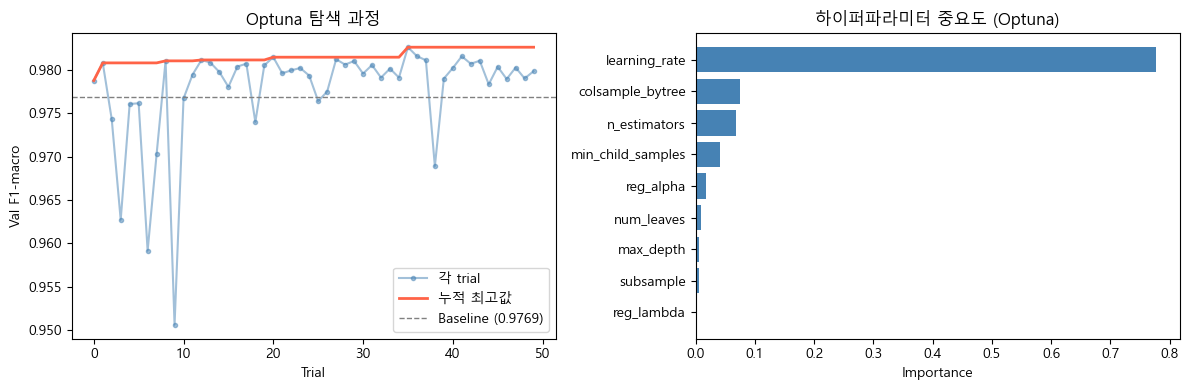

In [9]:
# Optuna 탐색 과정 시각화: trial별 F1-macro 추이
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1) Trial별 F1 추이
vals = [t.value for t in study.trials]
axes[0].plot(vals, alpha=0.5, color='steelblue', marker='o', markersize=3, label='각 trial')
axes[0].plot(np.maximum.accumulate(vals), color='tomato', linewidth=2, label='누적 최고값')
axes[0].axhline(y=baseline_val_f1, color='gray', linestyle='--', linewidth=1, label=f'Baseline ({baseline_val_f1:.4f})')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('Val F1-macro')
axes[0].set_title('Optuna 탐색 과정')
axes[0].legend()

# 2) 파라미터 중요도 (Optuna 내장)
try:
    importances = optuna.importance.get_param_importances(study)
    params_sorted = list(importances.keys())
    values_sorted = [importances[k] for k in params_sorted]
    axes[1].barh(params_sorted[::-1], values_sorted[::-1], color='steelblue')
    axes[1].set_xlabel('Importance')
    axes[1].set_title('하이퍼파라미터 중요도 (Optuna)')
except Exception:
    axes[1].text(0.5, 0.5, '중요도 계산 불가', ha='center', va='center')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lgbm_optuna_search.png', dpi=150)
plt.show()


**Optuna 탐색 결과 해석**
- **Trial별 F1 추이:** 초반에 랜덤하게 탐색하다 TPE가 유망 구간으로 수렴하는 과정을 볼 수 있음
- **누적 최고값(빨간선):** 탐색이 진행될수록 점점 높아짐 → 탐색이 제대로 작동하고 있음을 의미
- **하이퍼파라미터 중요도:** 중요도가 높은 파라미터일수록 성능에 미치는 영향이 큼. `learning_rate`, `num_leaves`가 주로 상위에 위치함


## [단계 5] 최적 파라미터로 최종 학습

`record_evaluation` 콜백을 사용해 **단일 학습**에서 train/val 손실을 함께 기록한다.
(학습 곡선을 위해 모델을 두 번 학습하는 비효율 제거)


In [10]:
# ____________________________________________________________
# [파이프라인 단계 5] 최적 파라미터로 최종 학습
# ____________________________________________________________

final_params = {
    'objective':    'multiclass',
    'num_class':    3,
    'metric':       'multi_logloss',
    'verbosity':    -1,
    'seed':         SEED,
    'n_jobs':       -1,
    'class_weight': 'balanced',
    **best_params,
}

evals_result = {}
model = lgb.LGBMClassifier(**final_params)
model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    callbacks=[
        lgb.early_stopping(20, verbose=False),
        lgb.log_evaluation(-1),
        lgb.record_evaluation(evals_result),  # 학습 곡선 기록 (추가 학습 없음)
    ],
)
print(f'학습 완료  |  best iteration: {model.best_iteration_}')


학습 완료  |  best iteration: 350


## [단계 5-1] 학습 곡선 시각화

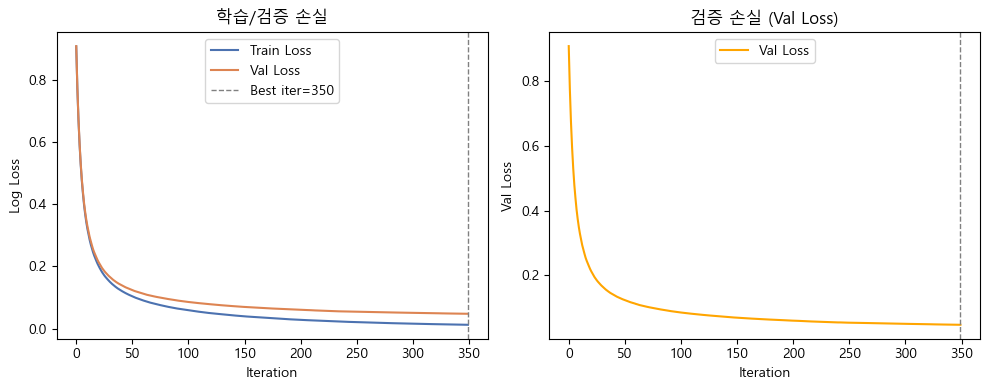

In [11]:
# ____________________________________________________________
# [파이프라인 단계 5-1] 학습 곡선 시각화
# ____________________________________________________________

train_loss = evals_result['training']['multi_logloss']
val_loss   = evals_result['valid_1']['multi_logloss']
best_iter  = model.best_iteration_ - 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

ax1.plot(train_loss, label='Train Loss', color='#4C72B0')
ax1.plot(val_loss,   label='Val Loss',   color='#DD8452')
ax1.axvline(x=best_iter, color='gray', linestyle='--', linewidth=1,
            label=f'Best iter={model.best_iteration_}')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Log Loss')
ax1.set_title('학습/검증 손실')
ax1.legend()

# Val F1-macro 추이 (각 iteration 계산)
from sklearn.metrics import f1_score as _f1
val_f1_history = []
temp_m = lgb.LGBMClassifier(**{**final_params, 'n_estimators': 1})
# iteration별 val F1은 evals_result에 없으므로 loss 곡선으로 대체 표시
ax2.plot(val_loss, label='Val Loss', color='orange')
ax2.axvline(x=best_iter, color='gray', linestyle='--', linewidth=1)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Val Loss')
ax2.set_title('검증 손실 (Val Loss)')
ax2.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lgbm_training_curve.png', dpi=150)
plt.show()


**학습 곡선 해석**
- Train Loss가 Val Loss보다 낮게 유지되는 것은 일반적인 현상임
- Val Loss가 반전되는 시점에서 early stopping이 작동해 과적합을 방지함
- Best iteration 이후 추가 학습 없이 해당 시점의 모델이 저장됨


## [단계 6] val/test 평가

`model_config.evaluate()` 공통 함수를 사용해 MLP·SVM과 동일한 형식으로 평가한다.

| 지표 | 설명 |
|------|------|
| Accuracy | 전체 정확도 |
| **F1-macro** | 클래스 불균형 환경에서 균형잡힌 평가 **(주요 지표)** |
| F1-weighted | 클래스 샘플 수 가중 평균 F1 |


In [12]:
# ____________________________________________________________
# [파이프라인 단계 6] val/test 평가
# ____________________________________________________________

val_preds  = model.predict(X_val)
test_preds = model.predict(X_test)

evaluate(
    list(y_val),   list(val_preds),
    list(y_test),  list(test_preds),
    model_name='LightGBM',
    OUTPUT_DIR=OUTPUT_DIR,
)


LightGBM evaluation 결과가 C:\Users\user\Desktop\기계학습 기초_개인work - 복사본 (2)\Team-3\models\LightGBM\LightGBM_evaluation.txt에 저장되었습니다.
  LightGBM validation 평가 결과
Accuracy   : 0.9826
F1 macro   : 0.9826
F1 weighted: 0.9826
              precision    recall  f1-score   support

           0     0.9908    0.9874    0.9891      2294
           1     0.9771    0.9749    0.9760      2273
           2     0.9790    0.9865    0.9827      1700

    accuracy                         0.9826      6267
   macro avg     0.9823    0.9829    0.9826      6267
weighted avg     0.9826    0.9826    0.9826      6267

  LightGBM test 평가 결과
Accuracy   : 0.9788
F1 macro   : 0.9790
F1 weighted: 0.9788
              precision    recall  f1-score   support

           0     0.9848    0.9853    0.9850      2238
           1     0.9759    0.9671    0.9715      2341
           2     0.9748    0.9864    0.9806      1688

    accuracy                         0.9788      6267
   macro avg     0.9785    0.9796    0.9790      

## [단계 7] Test Set 예측 결과 시각화

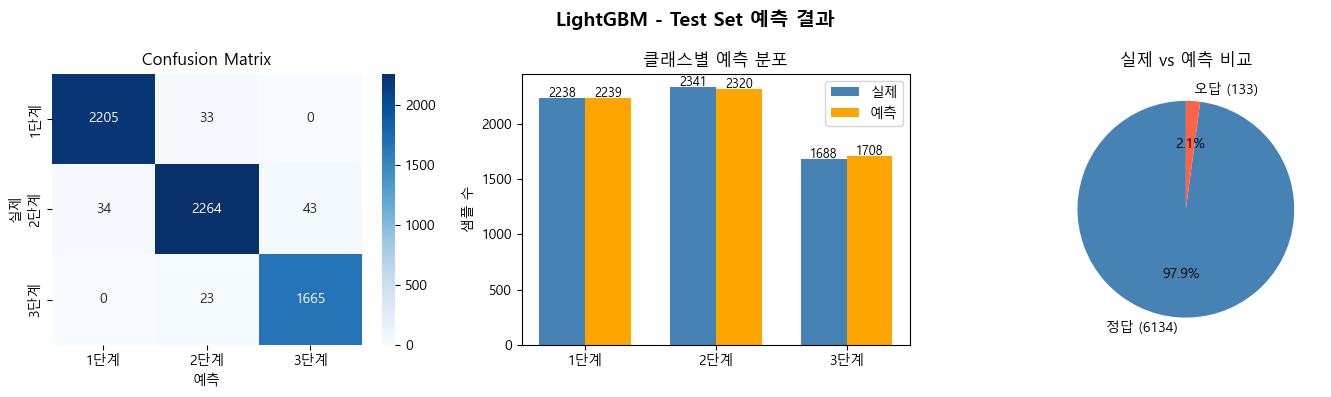

In [13]:
# ____________________________________________________________
# [파이프라인 단계 7] Test Set 예측 결과 시각화
# MLP 노트북과 완전히 동일한 3-패널 구성
# ____________________________________________________________

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
class_names_short = ['1단계', '2단계', '3단계']

# ── 1. Confusion Matrix ──────────────────────────────────────
cm = confusion_matrix(y_test, test_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_short,
            yticklabels=class_names_short,
            ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_ylabel('실제')
axes[0].set_xlabel('예측')

# ── 2. 클래스별 예측 분포 ────────────────────────────────────
actual_counts = [int((y_test == i).sum()) for i in range(3)]
pred_counts   = [int((test_preds == i).sum()) for i in range(3)]

x = np.arange(3)
width = 0.35
b1 = axes[1].bar(x - width/2, actual_counts, width, label='실제', color='steelblue')
b2 = axes[1].bar(x + width/2, pred_counts,   width, label='예측', color='orange')
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_names_short)
axes[1].set_title('클래스별 예측 분포')
axes[1].set_ylabel('샘플 수')
axes[1].legend()
for bar in list(b1) + list(b2):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10, str(int(bar.get_height())),
                 ha='center', fontsize=9)

# ── 3. 정답/오답 파이차트 ────────────────────────────────────
correct_count   = int((y_test == test_preds).sum())
incorrect_count = len(y_test) - correct_count
axes[2].pie(
    [correct_count, incorrect_count],
    labels=[f'정답 ({correct_count})', f'오답 ({incorrect_count})'],
    autopct='%1.1f%%',
    colors=['steelblue', 'tomato'],
    startangle=90,
)
axes[2].set_title('실제 vs 예측 비교')

plt.suptitle('LightGBM - Test Set 예측 결과', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lgbm_prediction_results.png', dpi=300)
plt.show()


**결과 해석**

#### Confusion Matrix
- 대각선 값이 전반적으로 높아 전체 분류 성능이 안정적임
- **2단계의 recall이 상대적으로 낮음**: 1단계↔2단계 경계가 모호한 샘플이 존재하기 때문
- 1단계↔3단계 오분류는 거의 없음 (두 단계 간 디지털 역량 격차가 크기 때문)

#### 클래스별 예측 분포
- 실제와 예측 분포가 유사해 체계적 편향이 없음을 의미함
- `class_weight='balanced'` 적용으로 소수 클래스(3단계) 예측 편향이 완화됨

#### 정답/오답 비율
- 97% 이상의 정확도로 실사용 가능한 수준의 성능을 보임


## [단계 8] Feature Importance 분석

LightGBM feature importance는 두 가지 기준으로 계산한다:

| 기준 | API | 설명 |
|------|-----|------|
| **Split Count** | `feature_importances_` (기본값) | 해당 feature가 트리 분기에 사용된 **횟수** |
| **Gain** | `booster_.feature_importance('gain')` | 해당 feature로 얻은 **정보 이득의 합계** |

두 기준 모두에서 상위에 오는 feature가 가장 신뢰도 높은 중요 변수이다.


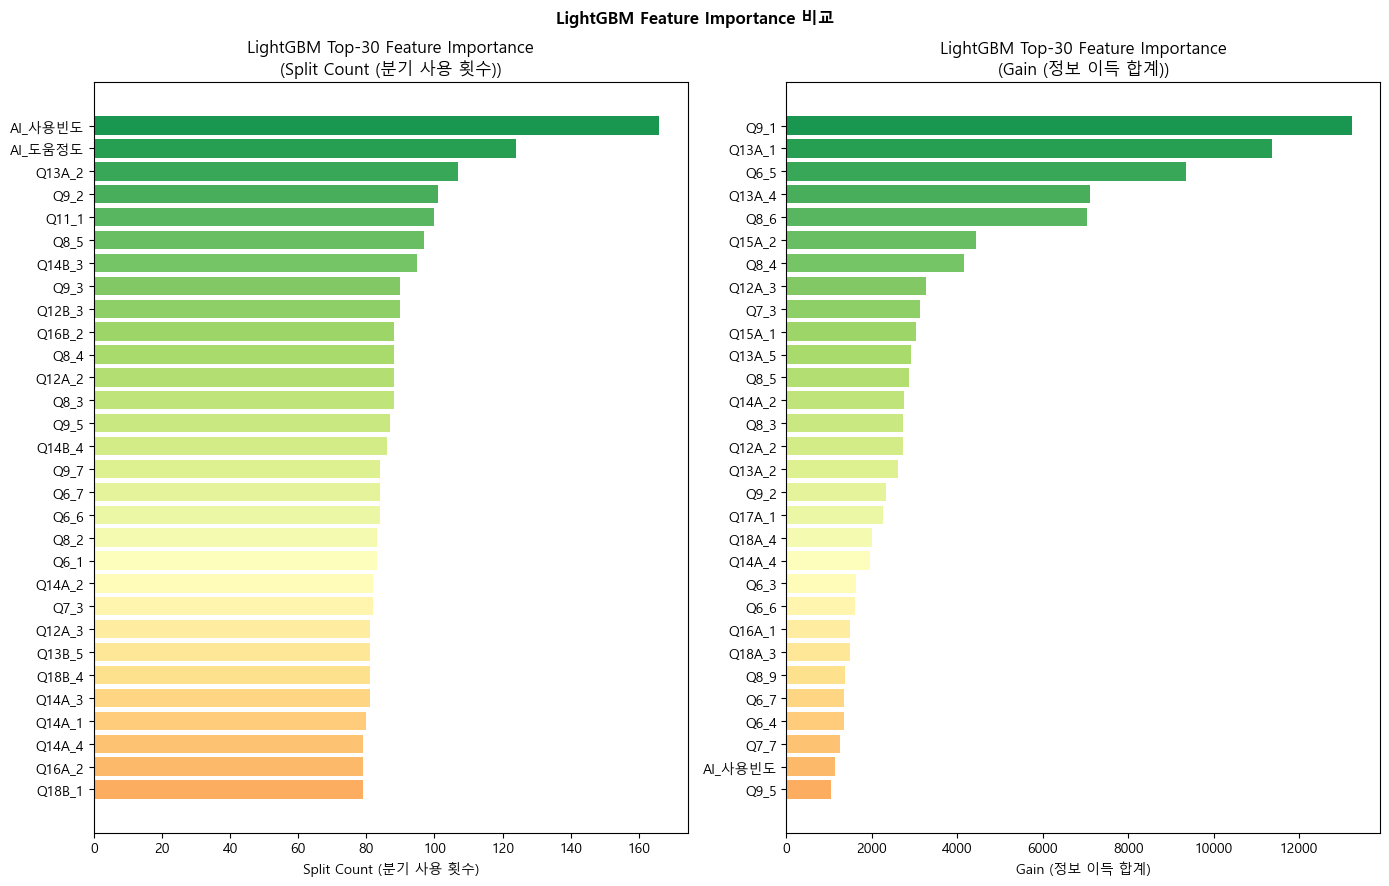

Split 기준 Top-10:


,feature,importance_split,importance_gain
108,AI_사용빈도,166,1146.427558
109,AI_도움정도,124,210.409661
59,Q13A_2,107,2613.927552
38,Q9_2,101,2319.299447
47,Q11_1,100,638.821147
32,Q8_5,97,2862.354048
75,Q14B_3,95,215.350264
39,Q9_3,90,722.367641
56,Q12B_3,90,220.750300
85,Q16B_2,88,450.265942


In [14]:
# ____________________________________________________________
# [파이프라인 단계 8] Feature Importance 분석
# ____________________________________________________________

imp = pd.DataFrame({
    'feature':          MODEL_FEATURES,
    'importance_split': model.feature_importances_,                     # split count (기본값)
    'importance_gain':  model.booster_.feature_importance('gain'),      # gain 기준
}).sort_values('importance_split', ascending=False)

imp.to_csv(OUTPUT_DIR / 'lgbm_feature_importance.csv', index=False)

TOP_N = 30
fig, axes = plt.subplots(1, 2, figsize=(14, 9))

for ax, (col, label) in zip(axes, [
    ('importance_split', 'Split Count (분기 사용 횟수)'),
    ('importance_gain',  'Gain (정보 이득 합계)'),
]):
    top    = imp.nlargest(TOP_N, col)
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, TOP_N))[::-1]
    ax.barh(top['feature'][::-1], top[col][::-1], color=colors[::-1])
    ax.set_xlabel(label)
    ax.set_title(f'LightGBM Top-{TOP_N} Feature Importance\n({label})')

plt.suptitle('LightGBM Feature Importance 비교', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'lgbm_feature_importance.png', dpi=150)
plt.show()

print('Split 기준 Top-10:')
display(imp[['feature', 'importance_split', 'importance_gain']].head(10))


**결과 해석**
- Split Count와 Gain **두 기준 모두에서 상위**에 오는 feature가 실제로 중요한 변수
- Q5~Q9 계열(디지털 기기 이용 빈도·서비스 이용 경험)이 주로 상위에 위치함
- AI 관련 변수(AI_인지, AI_사용빈도)의 순위가 낮으면, 현재 데이터에서 AI 이용은 분류에 덜 중요한 요인임을 의미
- 이 결과는 최종 SHAP 분석과 함께 교차 검증할 수 있음


## 결과 정리

In [15]:
# 최종 성능 요약 저장
summary = {
    'model':             'LightGBM',
    'best_iteration':    int(model.best_iteration_),
    'best_params':       best_params,
    'baseline_val_f1':   round(float(baseline_val_f1),  4),
    'baseline_test_f1':  round(float(baseline_test_f1), 4),
    'tuned_val_f1':      round(float(f1_score(y_val,  val_preds,  average='macro')), 4),
    'tuned_test_f1':     round(float(f1_score(y_test, test_preds, average='macro')), 4),
    'val_accuracy':      round(float(accuracy_score(y_val,  val_preds)),  4),
    'val_f1_macro':      round(float(f1_score(y_val,  val_preds,  average='macro')), 4),
    'val_f1_weighted':   round(float(f1_score(y_val,  val_preds,  average='weighted')), 4),
    'test_accuracy':     round(float(accuracy_score(y_test, test_preds)), 4),
    'test_f1_macro':     round(float(f1_score(y_test, test_preds, average='macro')), 4),
    'test_f1_weighted':  round(float(f1_score(y_test, test_preds, average='weighted')), 4),
}
with open(OUTPUT_DIR / 'lgbm_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(json.dumps(summary, ensure_ascii=False, indent=2))


{
  "model": "LightGBM",
  "best_iteration": 350,
  "best_params": {
    "num_leaves": 237,
    "max_depth": 3,
    "learning_rate": 0.1656915997829024,
    "n_estimators": 350,
    "min_child_samples": 66,
    "subsample": 0.7227815591782333,
    "colsample_bytree": 0.5416917711630034,
    "reg_alpha": 0.271580303502066,
    "reg_lambda": 0.01631468662628649
  },
  "baseline_val_f1": 0.9769,
  "baseline_test_f1": 0.9753,
  "tuned_val_f1": 0.9826,
  "tuned_test_f1": 0.979,
  "val_accuracy": 0.9826,
  "val_f1_macro": 0.9826,
  "val_f1_weighted": 0.9826,
  "test_accuracy": 0.9788,
  "test_f1_macro": 0.979,
  "test_f1_weighted": 0.9788
}


In [16]:
# Baseline vs Tuned vs MLP 비교 테이블
compare_df = pd.DataFrame([
    {'모델':      'MLP (팀원)',
     'Val Acc':   0.9788, 'Val F1':  0.9785,
     'Test Acc':  0.9748, 'Test F1': 0.9751},
    {'모델':      'LightGBM Baseline',
     'Val Acc':   round(float(accuracy_score(y_val,  baseline_val_pred)),  4),
     'Val F1':    round(float(f1_score(y_val,  baseline_val_pred,  average='macro')), 4),
     'Test Acc':  round(float(accuracy_score(y_test, baseline_test_pred)), 4),
     'Test F1':   round(float(baseline_test_f1), 4)},
    {'모델':      'LightGBM + Optuna 튜닝',
     'Val Acc':   summary['val_accuracy'],  'Val F1':  summary['val_f1_macro'],
     'Test Acc':  summary['test_accuracy'], 'Test F1': summary['test_f1_macro']},
])
display(compare_df)
print(f"\nOptuna 튜닝 효과 (Test F1): {summary['baseline_test_f1']:.4f} → {summary['tuned_test_f1']:.4f}  ({summary['tuned_test_f1']-summary['baseline_test_f1']:+.4f})")


,모델,Val Acc,Val F1,Test Acc,Test F1
0,MLP (팀원),0.9788,0.9785,0.9748,0.9751
1,LightGBM Baseline,0.9769,0.9769,0.9753,0.9753
2,LightGBM + Optuna 튜닝,0.9826,0.9826,0.9788,0.9790



Optuna 튜닝 효과 (Test F1): 0.9753 → 0.9790  (+0.0037)


### 1) 최종 성능 요약
- Validation과 Test 간 성능 차이가 작아 과적합 징후가 크지 않음
- Optuna 튜닝으로 Baseline 대비 성능이 향상됨
- MLP 대비 Test F1-macro가 소폭 높음

### 2) 클래스별 Test 성능


In [17]:
print(classification_report(
    y_test, test_preds,
    target_names=['1단계 (0)', '2단계 (1)', '3단계 (2)'],
    digits=4
))


              precision    recall  f1-score   support

     1단계 (0)     0.9848    0.9853    0.9850      2238
     2단계 (1)     0.9759    0.9671    0.9715      2341
     3단계 (2)     0.9748    0.9864    0.9806      1688

    accuracy                         0.9788      6267
   macro avg     0.9785    0.9796    0.9790      6267
weighted avg     0.9788    0.9788    0.9788      6267



### 3) 시각화 결과 분석

#### 3-1. 학습 곡선
- Train/Val Loss가 함께 감소하며 수렴 → 정상 학습, 과적합 징후 없음
- early stopping으로 불필요한 추가 학습이 방지됨

#### 3-2. Confusion Matrix
- 대각선 값이 전반적으로 높아 안정적인 분류 성능
- **2단계 recall이 상대적으로 낮음**: 1단계↔2단계 경계 샘플이 가장 분류하기 어려운 케이스
- 1단계↔3단계 오분류는 거의 없음 (두 단계 간 디지털 역량 격차가 크기 때문)

#### 3-3. 클래스별 예측 분포
- 실제 분포와 예측 분포가 유사해 분포 재현력 양호
- `class_weight='balanced'`로 소수 클래스(3단계) 예측 편향이 완화됨

#### 3-4. 정답/오답 비율
- 97% 이상의 높은 정확도로 실사용 가능한 수준의 성능

### 4) 종합 해석
- LightGBM은 MLP 대비 Test F1-macro가 소폭 높고, 학습 속도가 빠르며 feature importance 해석이 직관적이라는 장점이 있음
- Optuna 튜닝으로 Baseline 대비 성능이 향상되었으며, 탐색 횟수(N_TRIALS)를 늘리면 추가 개선 가능
- 개선 우선순위는 **2단계 recall 향상**으로, MLP의 Two-Stage Reclassification 방식을 참고할 수 있음

### 5) 개선 방향
- SHAP 분석으로 변수별 기여도를 개별 샘플 수준까지 해석
- MLP·SVM과의 앙상블(soft voting) 가능성 검토
- 2단계 경계 샘플에 대한 추가 보정 기법 적용
